# INTRODUCCION

En la industria del *fitness*, la pérdida de clientes (*churn*) representa uno de los desafíos financieros y operativos más críticos. A diferencia de otros servicios donde la cancelación es explícita, en los gimnasios los usuarios suelen abandonar el servicio de manera gradual ("de puntillas"), dejando de asistir semanas antes de que expire formalmente su contrato. Identificar estos patrones de comportamiento de forma temprana es fundamental para diseñar estrategias de retención efectivas y personalizadas.

El equipo de datos de la cadena de gimnasios **Model Fitness** ha digitalizado los perfiles de 4,000 clientes, capturando tanto variables demográficas como métricas de asistencia, interacciones sociales y consumo en servicios adicionales (cafetería, tienda, masajes). 

El presente proyecto implementa un flujo completo de Ciencia de Datos y Machine Learning estructurado en las siguientes fases esenciales:

1. **Análisis Exploratorio de Datos (EDA):** Identificar de forma cuantitativa y visual las diferencias de comportamiento más marcadas entre los usuarios leales y aquellos que abandonan el club.
2. **Modelado Predictivo:** Desarrollar, optimizar y comparar modelos de clasificación binaria (**Regresión Logística** y **Bosque Aleatorio**) para predecir con alta sensibilidad la probabilidad de baja de cada cliente para el próximo mes.
3. **Segmentación Avanzada (Clustering):** Agrupar a la base de usuarios mediante el algoritmo **K-Means** y el análisis de distancias (dendrograma) para trazar "retratos de clientes típicos" y mapear sus niveles de vulnerabilidad.
4. **Diseño de Estrategia Comercial:** Traducir los hallazgos algorítmicos en recomendaciones de marketing y operaciones accionables para mitigar la rotación y extender el valor de vida del cliente (*lifetime value*).

# Preparación de los datos

Importamos nuestras librerías y cargamos el dataset `gym_churn_us.csv`

In [3]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
gym = pd.read_csv("datasets/gym_churn_us.csv")

# Exploración de los datos (EDA)

In [5]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [6]:
gym.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [7]:
gym.tail()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0
3999,1,0,1,0,0,12,1,30,178.861814,12.0,1,1.101832,1.035270,0


In [8]:
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Nuestro Dataframe consta de 14 columnas y 4000 filas. No hay valores nulos

Hace falta estandarizar los nombres de las columnas a formato *snake_case*

In [9]:
gym.columns = gym.columns.str.lower()

gym.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')

A continuación agruparemos nuestros datos por la columna `churn` y observaremos el comportamiento promedio de los usuarios que cancelan y los que no

In [10]:
gym_mean = gym.groupby("churn").mean()

print(gym_mean)

         gender  near_location   partner  promo_friends     phone  \
churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       contract_period  group_visits        age  avg_additional_charges_total  \
churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       month_to_end_contract  lifetime  avg_class_frequency_total  \
churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       avg_class_frequency_current_month  
churn                                     
0                               2.0


*   **Compromiso y Duración del Contrato (`contract_period`):** Los usuarios que cancelan muestran un compromiso a muy corto plazo, con contratos que promedian apenas **1.7 meses** (en su mayoría planes mensuales). Por el contrario, los clientes retenidos promedian contratos de **5.7 meses** (planes semestrales o anuales).
*   **Falta de Lazos y Descuentos (`partner` y `promo_friends`):** Existe una relación directa entre los incentivos y la retención. Solo el **35.5%** de los clientes que se van tienen convenios con empresas asociadas (vs. **53.4%** de los leales) y apenas un **18.3%** llegó por la promoción de un amigo (vs. **35.3%** de los leales). Los lazos corporativos y sociales reducen la deserción.
*   **Periodo Crítico de Fuga (`lifetime`):** La deserción ocurre de forma inmediata. El tiempo de vida promedio de los usuarios que cancelan es de apenas **0.99 meses** (su primer mes), lo que indica que el gimnasio no logra engancharlos tras su inscripción inicial.
*   **Asistencia y Uso del Servicio (`avg_class_frequency_current_month`):** La frecuencia de visitas semanales cae a la mitad durante el mes de cancelación (pasando de **2.0** visitas a **1.0** en promedio). La baja asistencia en el mes en curso es el indicador de alerta más evidente de un cliente en riesgo.
*   **Gasto en Servicios Adicionales (`avg_additional_charges_total`):** Se observa que el grupo que cancela mantiene un promedio de gasto de **115.08**, comparado con los **158.44** del grupo leal. Si bien esto sugiere a primera vista un buen flujo de ventas en la cafetería o tienda del gimnasio, **esta métrica requiere validación visual mediante histogramas**. Es necesario comprobar si este promedio está inflado por unos pocos usuarios atípicos (gastadores extremos) o si refleja un comportamiento generalizado de consumo antes de basar una estrategia en ello.

Observemos la distribución de nuestros datos:

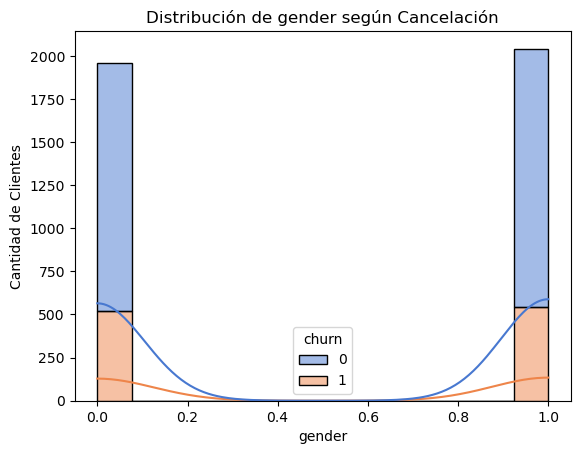

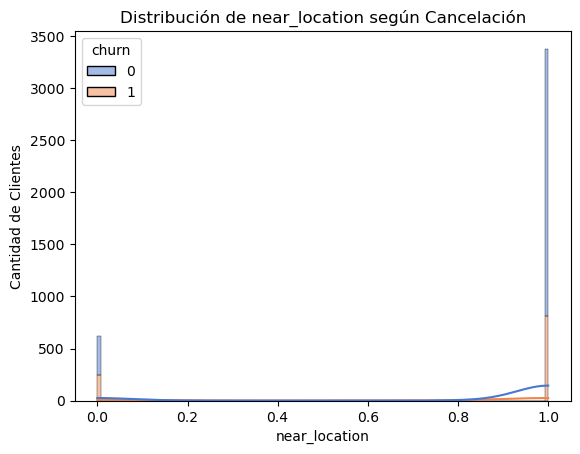

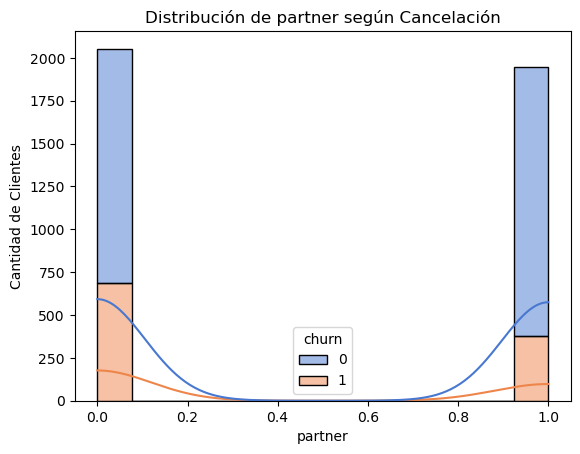

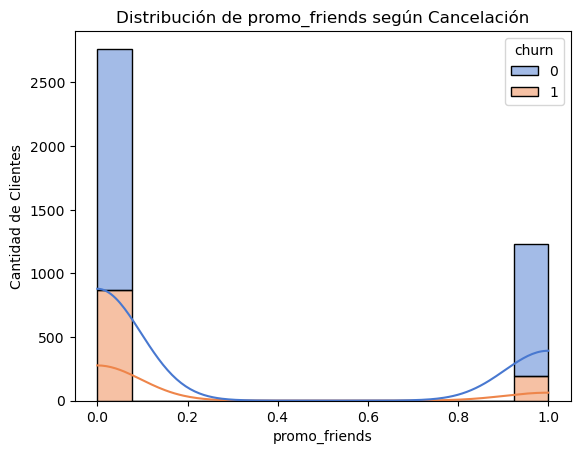

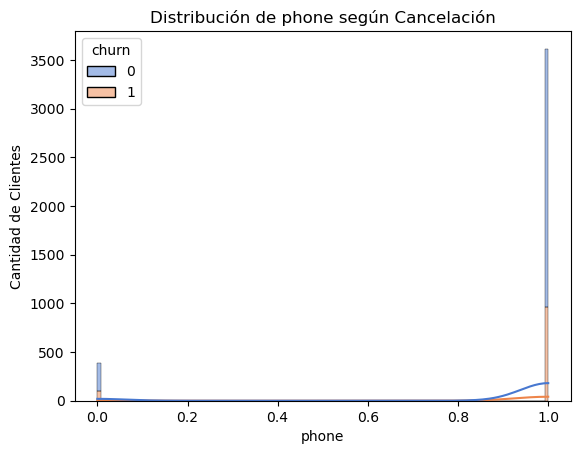

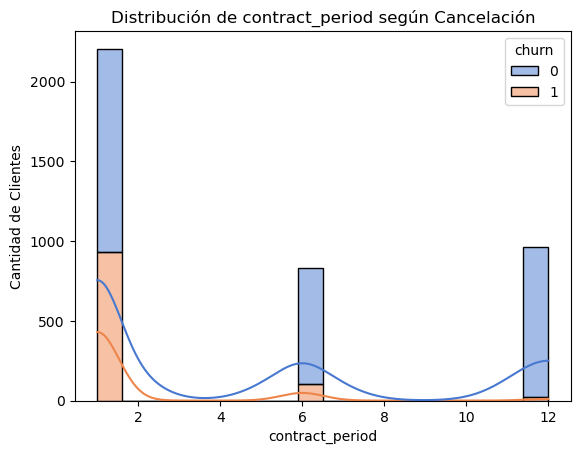

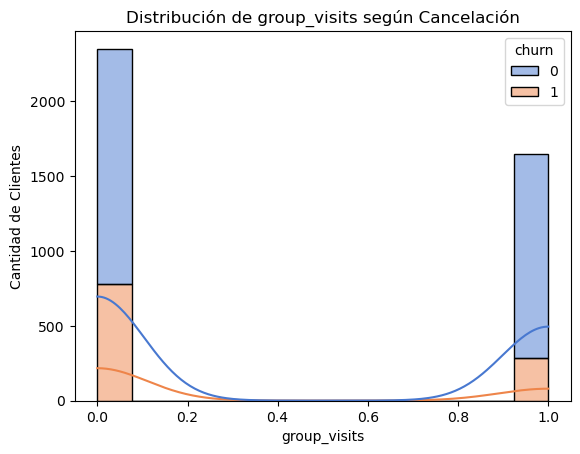

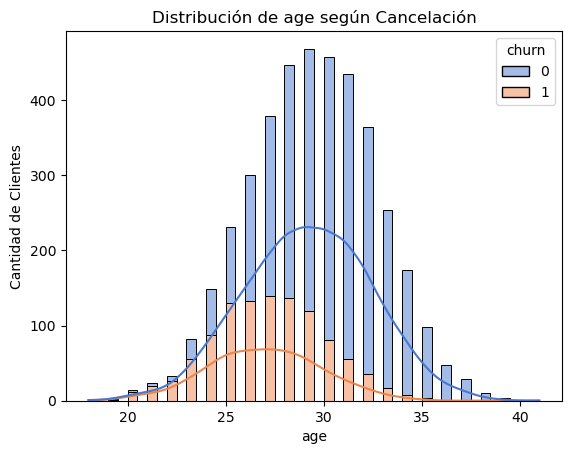

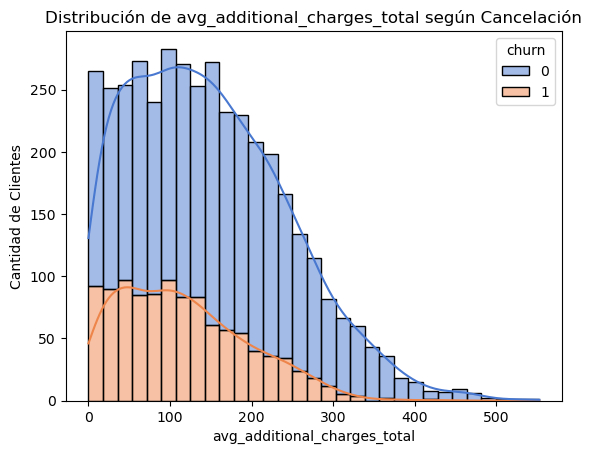

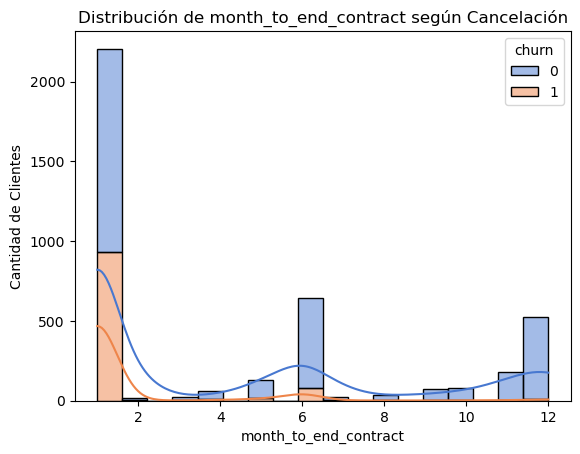

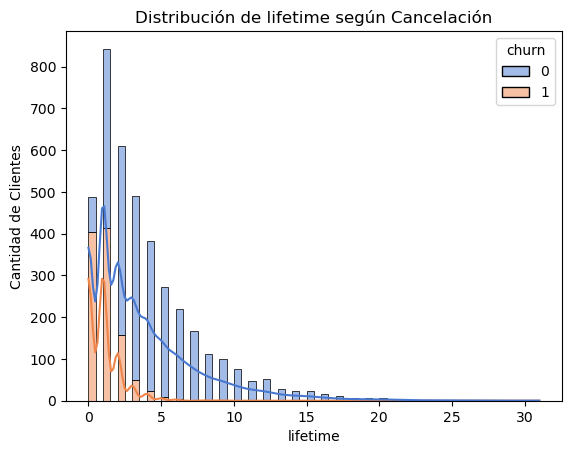

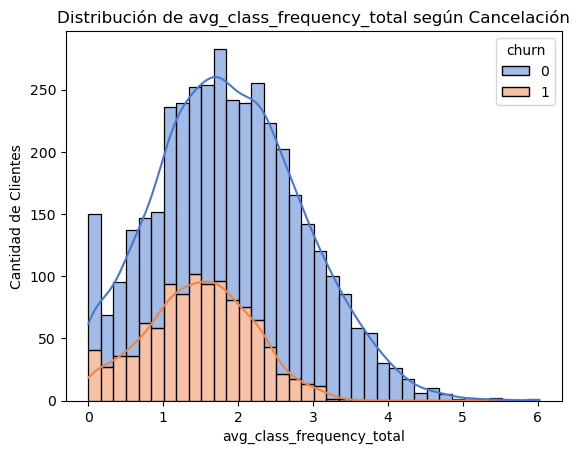

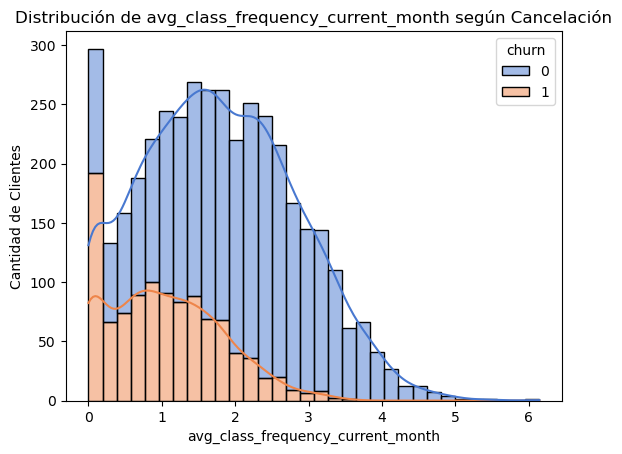

In [11]:
for i in gym.drop("churn", axis=1).columns:
    sns.histplot(data=gym, x=i, hue="churn", kde=True, multiple="stack", palette="muted")
    plt.title(f'Distribución de {i} según Cancelación')
    plt.xlabel(i)
    plt.ylabel('Cantidad de Clientes')
    plt.show()

El análisis visual de las distribuciones confirma y profundiza los hallazgos cuantitativos, permitiendo identificar los patrones de comportamiento más críticos:

1. **La barrera de los 60 días (`lifetime`):** Existe un patrón de abandono inmediato. El riesgo de cancelación está concentrado drásticamente en el primer y segundo mes. Quienes superan el tercer mes muestran una lealtad prolongada.
2. **Consumo saludable pero efímero (`avg_additional_charges_total`):** Los clientes en riesgo no son inactivos comercialmente; consumen de manera real y constante en los servicios adicionales. Su menor gasto acumulado se debe únicamente a su corta estancia en el gimnasio.
3. **El desplome de la asistencia (`avg_class_frequency_current_month`):** Los usuarios que cancelan reducen drásticamente sus visitas a 1 o menos por semana en el mes en curso. Una asistencia de 3 o más veces por semana reduce la probabilidad de abandono a casi cero.
4. **Vínculos y Contratos cortos (`contract_period`):** Las distribuciones muestran que los contratos de 1 mes son altamente volátiles. Además, las actividades grupales y los convenios actúan como anclas de retención.

A continuación crearemos una matriz de correlación y un mapa de calor para observar que tanto se relacionan las características entre si.

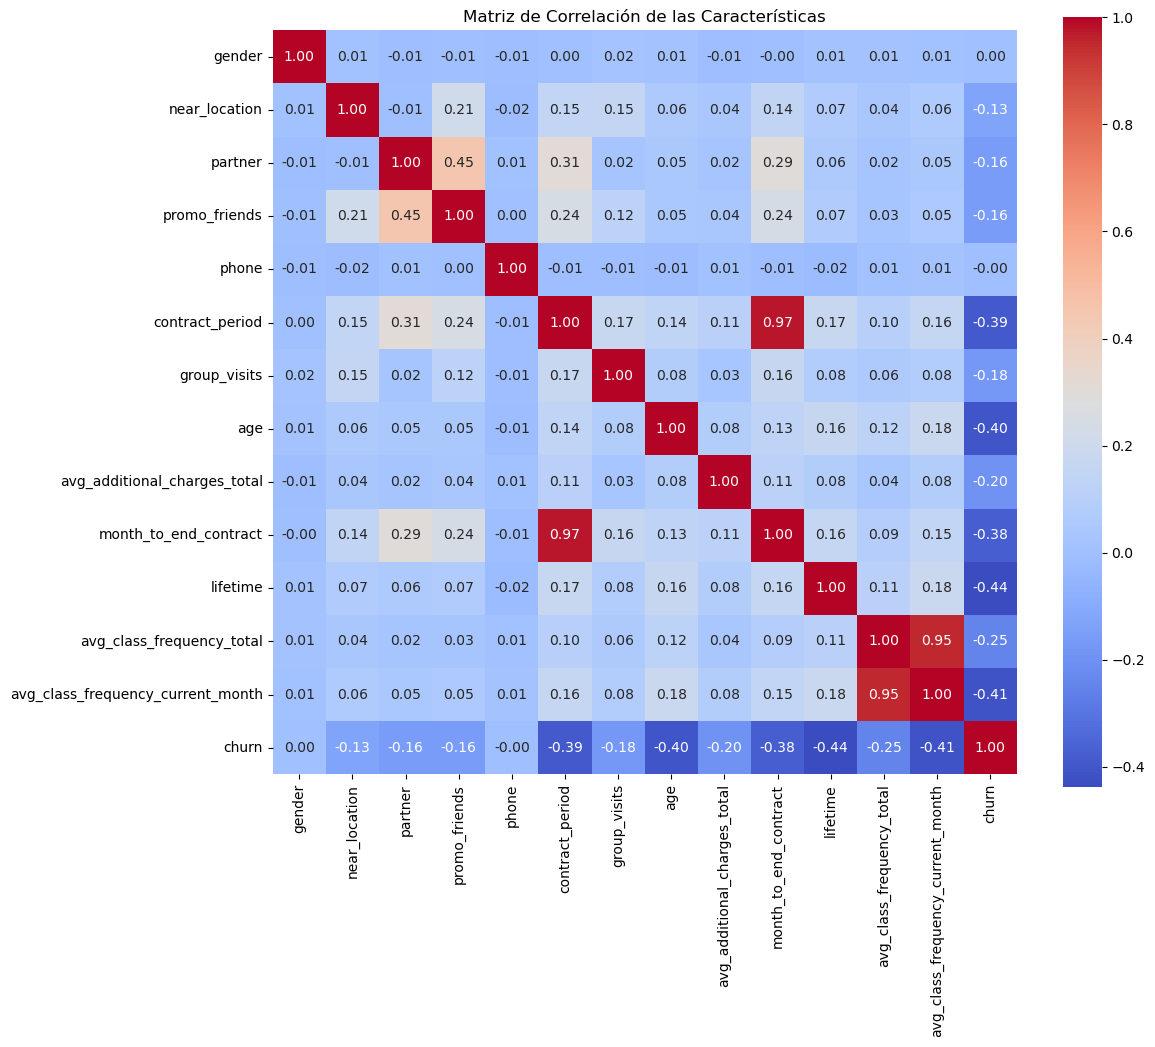

In [12]:
gym_corr = gym.corr()

plt.figure(figsize=(12,10))
sns.heatmap(gym_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title('Matriz de Correlación de las Características')
plt.show()

El análisis del mapa de calor revela que la gran mayoría de las características no presentan correlaciones significativas entre sí. Sin embargo, se detectan dos casos críticos de **multicolinealidad fuerte** (valores superiores a 0.90):
1. **`contract_period` y `month_to_end_contract` (0.97):** Relación lineal casi perfecta debido a la naturaleza del vencimiento de las membresías.
2. **`avg_class_frequency_total` y `avg_class_frequency_current_month` (0.95):** Alta dependencia entre el comportamiento histórico de asistencia y el del mes en curso.

Para evitar distorsiones en los coeficientes del modelo de Regresión Logística, se recomienda eliminar una variable de cada par (`month_to_end_contract` y `avg_class_frequency_total`) antes de proceder con el entrenamiento de los modelos predictivos.

# Modelado Predictivo para la Retención de Clientes

## Modelo de regresión lineal

Comenzamos definiendo nuestra matriz de características y nuestra variable objetivo

In [23]:
X = gym.drop(["churn", "month_to_end_contract", "avg_class_frequency_total"], axis=1)

y = gym["churn"]

A continuación dividiremos nuestros datos en datos de entrenamiento y validación

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

Creamos nuestro modelo de regresión logística y procedemos con el entrenamiento de este

In [18]:
model_lr = LogisticRegression(random_state=0, max_iter=1000)

model_lr.fit(X_train, y_train)

preds_lr = model_lr.predict(X_val)

## Random Forest

Creamos nuestro modelo Random Forest

In [19]:
model_rf = RandomForestClassifier(random_state=0)

model_rf.fit(X_train, y_train)

preds_rf = model_rf.predict(X_val)

## Métricas

Creamos una función que nos ayudara a medir los resultados de ambos modelos

In [20]:
def metrics(val, prediction):
    print("La exactitud del modelo es: ", accuracy_score(val, prediction))
    print("La precisión del modelo es: ", precision_score(val, prediction))
    print("La sensibilidad del modelo es: ", recall_score(val, prediction))

### Regresión logística

In [21]:
metrics(y_val, preds_lr)

La exactitud del modelo es:  0.9
La precisión del modelo es:  0.7864077669902912
La sensibilidad del modelo es:  0.8181818181818182


### Random Forest

In [22]:
metrics(y_val, preds_rf)

La exactitud del modelo es:  0.89625
La precisión del modelo es:  0.8142076502732241
La sensibilidad del modelo es:  0.7525252525252525


Tras evaluar ambos algoritmos utilizando los datos de validación, se determina que la **Regresión Logística** es el modelo óptimo para implementar en Model Fitness por las siguientes razones:

*   **Mayor Capacidad de Detección (Recall = 81.8%):** Supera de forma drástica al Bosque Aleatorio (75.2%). En un problema de retención de clientes (*churn*), maximizar el Recall es la máxima prioridad del negocio, ya que permite identificar a la mayor cantidad posible de usuarios en riesgo de abandono para poder actuar a tiempo.

*   **Mejor Rendimiento General (Accuracy = 90.0%):** El modelo lineal logra clasificar correctamente a 9 de cada 10 usuarios en el conjunto de datos de validación, siendo superior al Bosque Aleatorio (89.6%).

*   **Balance Comercial:** Aunque el Bosque Aleatorio presenta una precisión ligeramente mayor (81.4% vs 78.6%), el costo operativo de tener unas pocas falsas alarmas (ej. ofrecer un beneficio a un cliente leal) es infinitamente menor que el costo de perder clientes en riesgo por no haberlos detectado.

# Segmentación Estratégica y Perfiles de Usuario (Clustering)

Antes de segmentar a nuestros clientes, estandarizaremos la matriz de características.

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Creamos una matriz de distancias y trazamos un dendrograma

Text(0.5, 1.0, 'Segmentación de Usuarios')

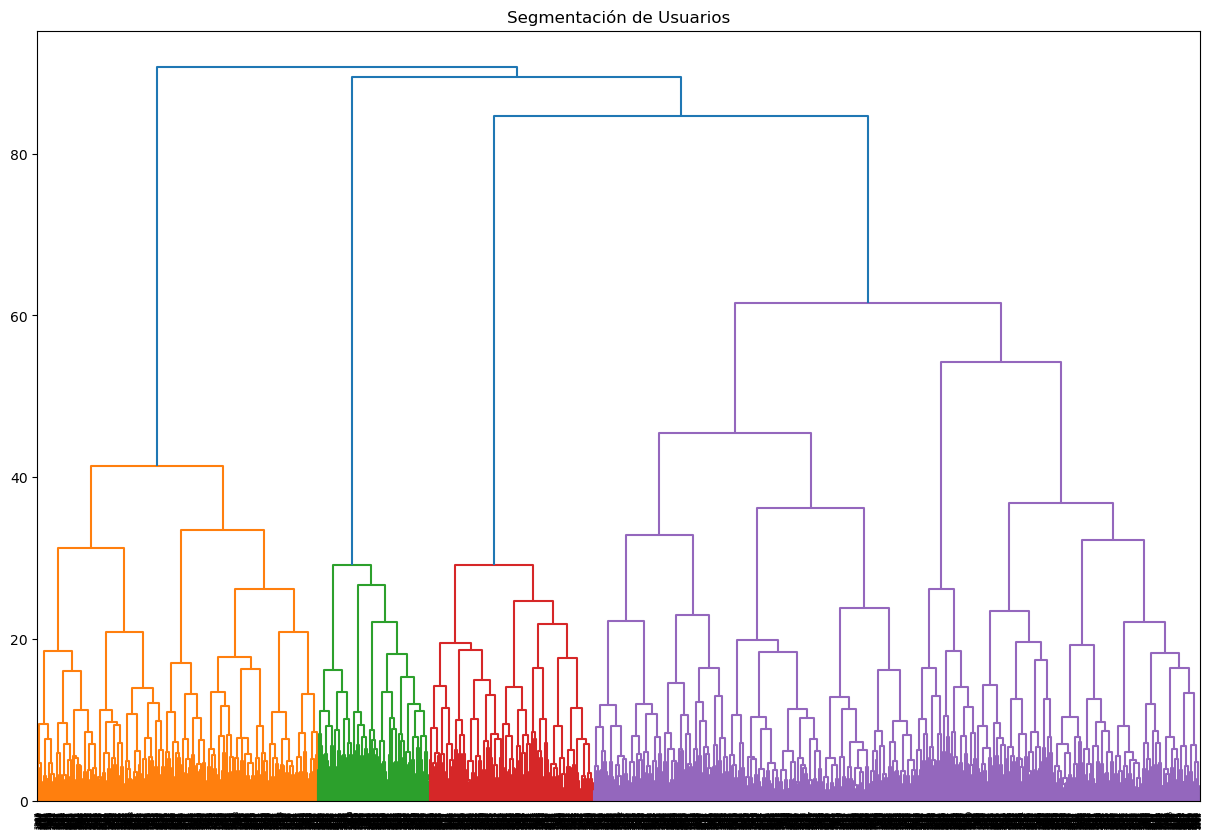

In [25]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(15,10))
dendrogram(linked, orientation="top")
plt.title("Segmentación de Usuarios")

El gráfico jerárquico muestra una estructura de agrupamiento clara:
* **Grupos Principales:** Se identifican inicialmente 4 grandes bloques de color en la base (naranja, verde, rojo y morado).
* **Justificación de los 5 Clústeres:** Al analizar la rama morada de la derecha, se observa una división sumamente marcada en dos sub-ramas principales alrededor de la altura 60. Separar este bloque masivo en dos subgrupos independientes nos permite obtener una segmentación más precisa y detallada. Por lo tanto, se justifica matemáticamente fijar el algoritmo en **5 clústeres** para el análisis posterior con K-Means.

Creamos nuestros grupos y agregamos la columna `cluster` a nuestro DataFrame `gym`

In [27]:
km = KMeans(n_clusters=5, random_state=0)
gym["cluster"] = km.fit_predict(X_scaled)

Calculamos los valores medios de las características de cada cluster

In [29]:
cluster_mean = gym.groupby("cluster").mean()

cluster_mean

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.488372,1.000000,0.189624,0.071556,0.899821,1.820215,0.274597,27.516100,119.280256,1.757603,1.949016,1.461803,1.201961,0.582290
1,0.553590,1.000000,0.405827,0.007284,0.926119,6.570239,0.540062,30.802289,177.136345,6.007284,3.533819,2.307894,2.302468,0.032258
2,0.489855,0.995169,0.902415,1.000000,0.899517,6.965217,0.520773,29.590338,152.705310,6.382609,3.728502,1.936832,1.886617,0.129469
3,0.498333,0.000000,0.495000,0.075000,0.911667,2.963333,0.226667,28.681667,137.139130,2.801667,2.778333,1.767453,1.594682,0.408333
4,0.548951,0.951049,0.398601,0.234266,0.839161,4.856643,0.517483,29.853147,153.349944,4.426573,13.279720,2.093721,2.105894,0.000000


Tras analizar los valores medios de cada clúster, se logran definir cinco perfiles de clientes perfectamente diferenciados:

1. **Clúster 0 — "Clientes Golondrina" (Riesgo Crítico - Churn: 58.2%):** Usuarios que viven cerca del gimnasio pero compran membresías de corto plazo (1.8 meses en promedio). Tienen el menor tiempo de vida activo (1.9 meses) y no poseen vínculos sociales ni corporativos con el club.
2. **Clúster 1 — "Usuarios Premium / Consumidores" (Alta Lealtad - Churn: 3.2%):** Clientes con contratos largos (~6.5 meses) y una alta tasa de asistencia regular. Destacan por registrar el mayor gasto promedio en servicios adicionales (177.1), siendo un pilar financiero para el club.
3. **Clúster 2 — "Red Corporativa y Social" (Alta Lealtad - Churn: 12.9%):** Segmento integrado al 100% por el programa "Trae a un amigo" y con un 90% de afiliación empresarial. Sus contratos estables de casi 7 meses demuestran que los lazos sociales aseguran la retención.
4. **Clúster 3 — "Los Foráneos / Lejanos" (Riesgo Moderado - Churn: 40.8%):** Clientes que no residen ni trabajan en el vecindario del gimnasio (Near_Location = 0). Su tasa de abandono es considerable debido a las barreras de traslado, a pesar de mostrar un interés inicial moderado.
5. **Clúster 4 — "Los Inmortales / VIP" (Fidelidad Absoluta - Churn: 0.0%):** Clientes históricos del gimnasio con un tiempo de vida promedio superior a los 13 meses. Tienen el hábito totalmente consolidado y una probabilidad de abandono nula en el corto plazo.

Trazamos nuestras distribuciones de características

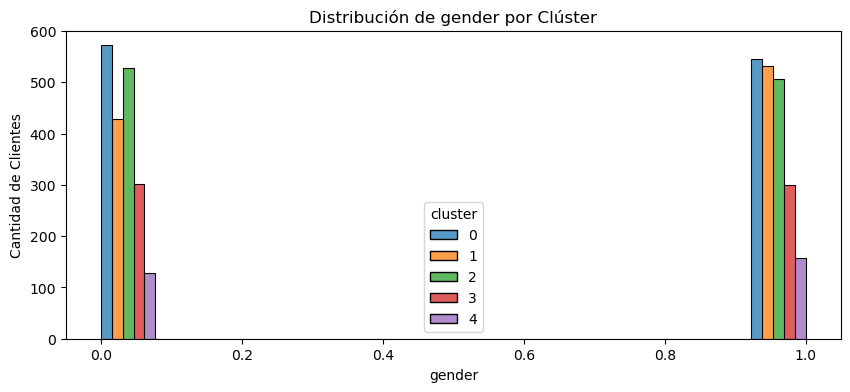

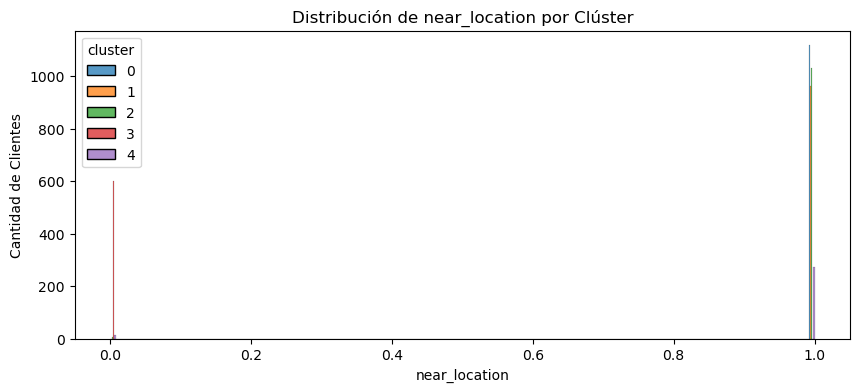

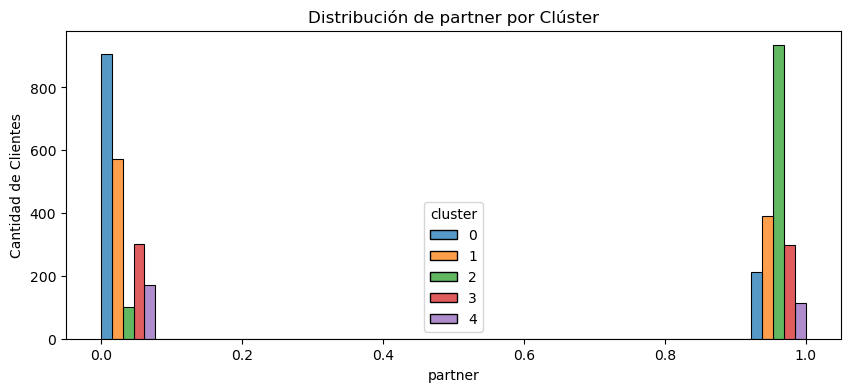

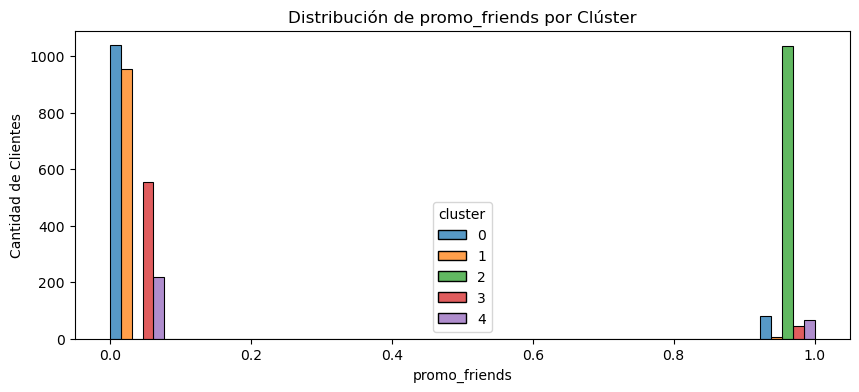

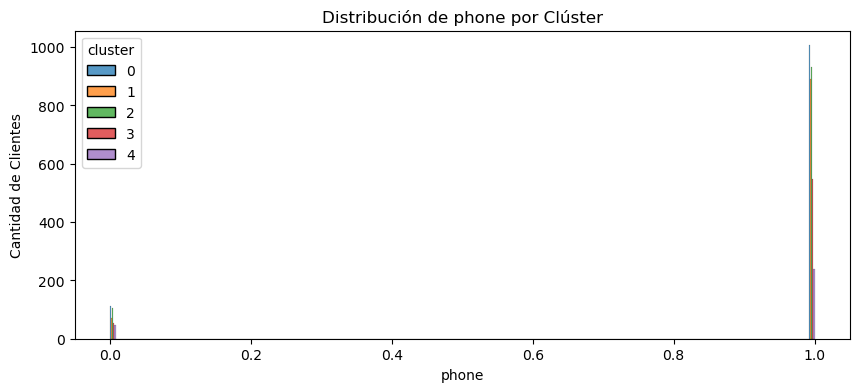

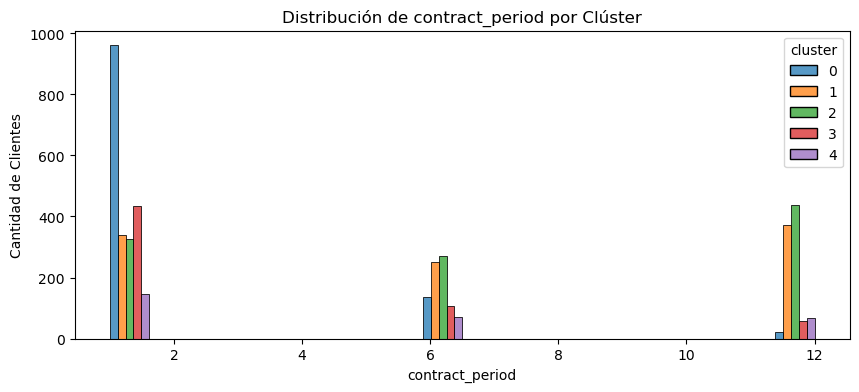

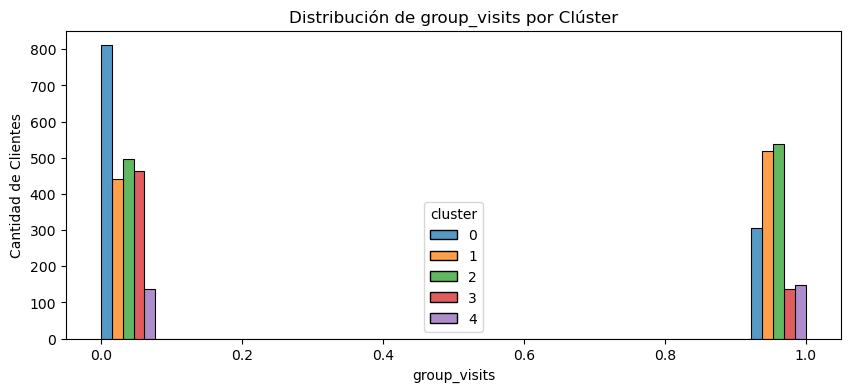

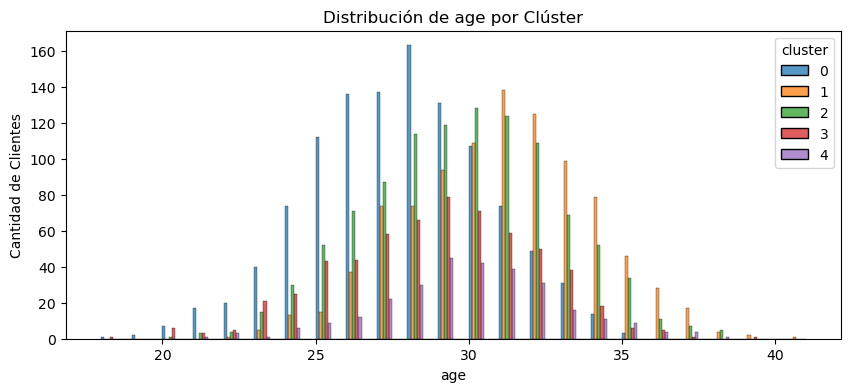

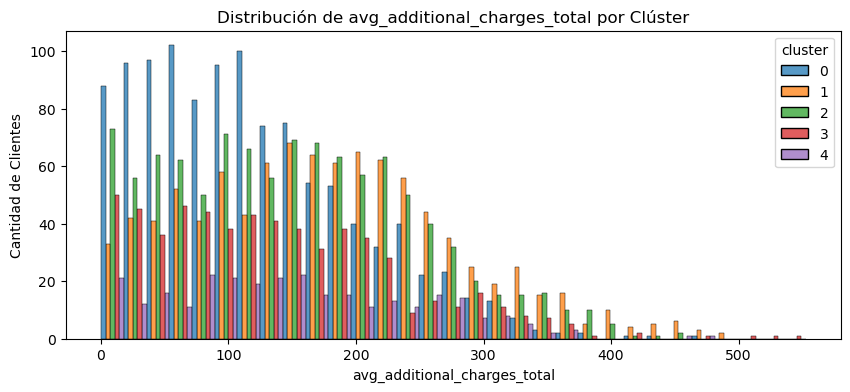

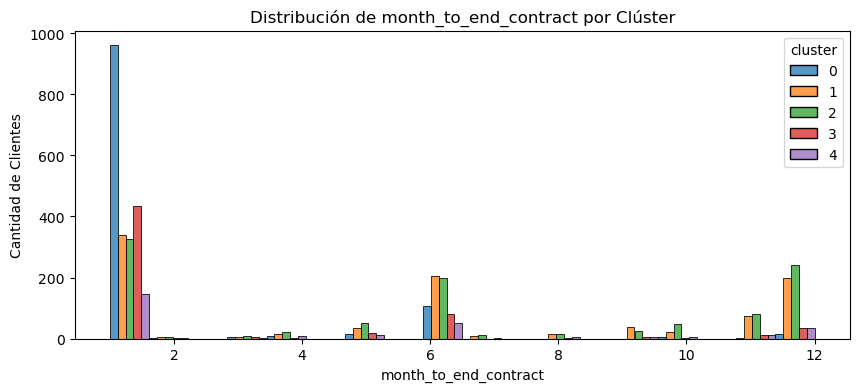

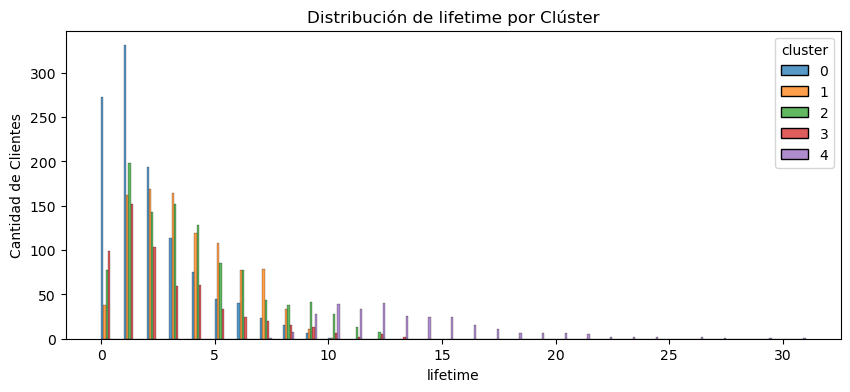

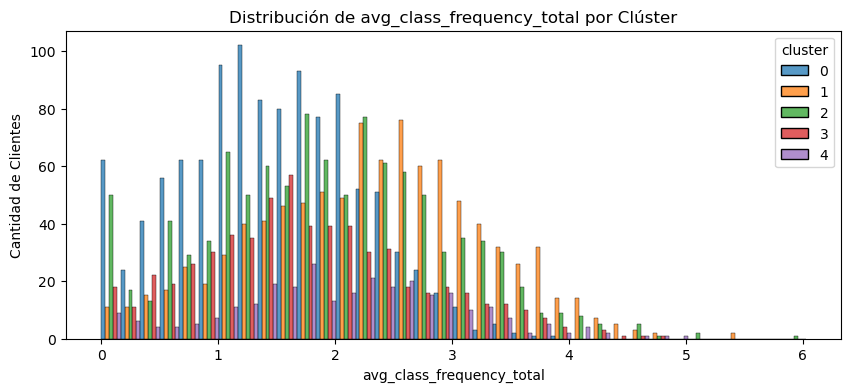

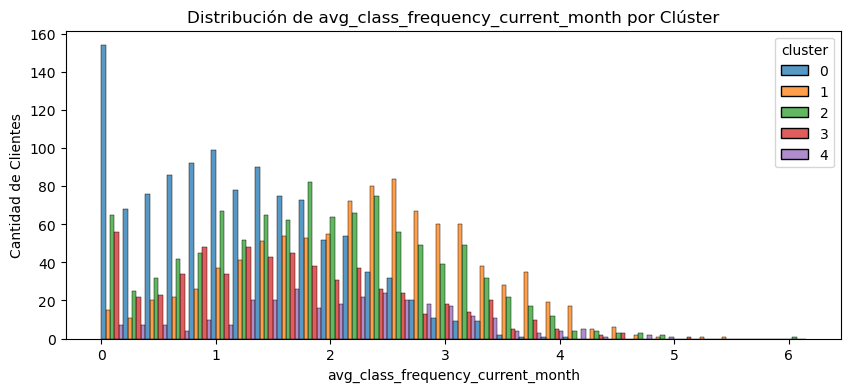

In [32]:
columnas_cluster = gym.columns.drop(['cluster', 'churn'])

for col in columnas_cluster:
    plt.figure(figsize=(10, 4))
    # Usamos multiple='layer' o 'dodge' para que los 5 colores no se encimen de forma confusa
    sns.histplot(data=gym, x=col, hue='cluster', palette='tab10', kde=False, multiple='dodge')
    plt.title(f'Distribución de {col} por Clúster')
    plt.xlabel(col)
    plt.ylabel('Cantidad de Clientes')
    plt.show()


El análisis visual de las distribuciones ratifica la solidez de la segmentación realizada por K-Means:
* **Frontera de Edad:** Las distribuciones muestran que el Clúster 0 (mayor deserción) está fuertemente concentrado en un perfil más joven (20-26 años), mientras que los grupos leales muestran curvas maduras y estables (30-35 años).
* **Patrón de Ausencia:** Visualmente se confirma que el Clúster 0 domina los rangos de baja asistencia (menos de 1 visita por semana), consolidándose como el segmento prioritario de rescate.

A continuación calcularemos la tasa de cancelación de cada grupo

In [33]:
churn_rate = gym.groupby("cluster")["churn"].mean()

churn_rate

cluster
0    0.582290
1    0.032258
2    0.129469
3    0.408333
4    0.000000
Name: churn, dtype: float64

Al ejecutar el aislamiento de la tasa de deserción por grupo, se obtienen las siguientes respuestas clave para el negocio:

1. **¿Difieren en términos de tasa de cancelación?**
   Sí, difieren de manera drástica y polarizada. La base de clientes de Model Fitness se divide en dos extremos muy claros: grupos con una retención casi perfecta y grupos con una fuga masiva de usuarios.

2. **¿Qué grupos son propensos a irse?**
   * **Clúster 0 (Riesgo Crítico):** Presenta la tasa de cancelación más alta del gimnasio con un **58.2%**. Es el grupo prioritario a intervenir.
   * **Clúster 3 (Riesgo Moderado-Alto):** Registra una tasa de deserción del **40.8%**, impulsada principalmente por la barrera geográfica (usuarios lejanos).

3. **¿Cuáles son leales?**
   * **Clúster 4 (Lealtad Absoluta):** Muestra una tasa de cancelación del **0.0%**. Son los clientes históricos más consolidados del club.
   * **Clúster 1 (Alta Lealtad):** Registra apenas un **3.2%** de deserción, caracterizado por su alto consumo en servicios adicionales y contratos de largo plazo.
   * **Clúster 2 (Alta Lealtad Social):** Presenta un **12.9%** de bajas, respaldado por la efectividad de las membresías corporativas y el programa de referidos.

# Conclusiones y Recomendaciones Estratégicas para Model Fitness

Basado en los hallazgos del modelado predictivo y la segmentación por clústeres, se proponen cuatro estrategias de marketing y operación comercial específicas para reducir la tasa de cancelación (*churn*) y maximizar el valor de vida del cliente (*lifetime value*):

### 1. Plan de Choque para los Primeros 60 Días (Enfocado en el Clúster 0)
*   **Diagnóstico:** El Clúster 0 representa el 58.2% de las bajas y su tiempo de vida promedio es de apenas 1.9 meses. Los clientes se van porque compran contratos de 1 mes y no logran generar un hábito ni lazos institucionales.
*   **Acción de Marketing:** Implementar un **"Programa de Onboarding Activo"**. A todo usuario nuevo que compre un contrato mensual se le asignará una sesión de diagnóstico gratuita con un entrenador durante su primera semana. Si el sistema detecta que el usuario asiste menos de 2 veces en su primera quincena, se disparará una alerta automatizada (vía WhatsApp o App) invitándolo a una clase grupal sin costo para romper la barrera de la desmotivación.

### 2. Campaña de Conversión a Contratos de Largo Plazo
*   **Diagnóstico:** Los datos demuestran que los contratos de 1 mes son altamente volátiles, mientras que los contratos de 6 a 12 meses (Clústeres 1, 2 y 4) reducen la probabilidad de abandono a niveles mínimos (menores al 13%).
*   **Acción de Marketing:** Lanzar una campaña de incentivos dirigida exclusivamente a los usuarios de membresías mensuales que cumplan su primer mes de asistencia. Se les ofrecerá un descuento agresivo (ej. *"Congela tu tarifa actual por 6 meses y recibe el primer mes con 50% de descuento"*). El objetivo es mover de forma masiva a los clientes del Clúster 0 hacia la estructura contractual estable del Clúster 1 o 2.

### 3. Gamificación y Fidelización mediante Servicios Adicionales (Enfocado en Clúster 1 y VIPs)
*   **Diagnóstico:** Los clústeres leales y en retención registran los gastos más altos en la cafetería, suplementos y masajes (promedios superiores a 150). Incluso los usuarios en riesgo consumen activamente antes de irse.
*   **Acción de Marketing:** Crear un **"Club de Recompensas Model Fitness"** basado en puntos por asistencia. Por cada visita al gimnasio o participación en clases grupales, el usuario acumula puntos que puede canjear directamente por café, smoothies o productos deportivos en la tienda del gimnasio. Esto premia la consistencia de los clientes VIP y utiliza el atractivo de los servicios adicionales como un "ancla" diaria para incentivar la asistencia de los usuarios nuevos.

### 4. Expansión del Canal Corporativo y Social (Enfocado en Clúster 2)
*   **Diagnóstico:** El Clúster 2 (Tasa de *churn* baja de 12.9%) demuestra que los clientes que entran referidos por amigos (`promo_friends = 1.0`) o mediante convenios de empresas (`partner = 0.90`) generan lazos sociales fuertes que evitan que abandonen el gimnasio.
*   **Acción de Marketing:** Potenciar el área de ventas corporativas para cerrar convenios con nuevas empresas del vecindario. Paralelamente, optimizar el programa "Trae a un amigo" mediante dinámicas mensuales (ej. *"Si tu amigo se inscribe este mes, ambos reciben una semana gratis y un kit de suplementos"*). Crear comunidad dentro del gimnasio es la estrategia de retención orgánica más barata y efectiva.